# IQR Technique for Outlier Detection

This note explains the Interquartile Range (IQR) method for detecting outliers and shows practical examples for detecting, trimming (removal), and capping (winsorizing) using IQR. Paste this whole markdown into a Jupyter Notebook markdown cell.

---

## 1. What is the IQR (Interquartile Range)

- Definitions:
  - Q1 (first quartile) = 25th percentile
  - Q3 (third quartile) = 75th percentile
  - IQR = Q3 − Q1
- Intuition:
  - IQR measures the spread of the middle 50% of the data. Values far outside this range are potential outliers.

---

## 2. Outlier fences (common rules)

- Regular fence (common rule):
  - Lower fence = Q1 − 1.5 × IQR
  - Upper fence = Q3 + 1.5 × IQR
  - Observations outside these fences are typically considered mild outliers.
- Extreme fence (more conservative):
  - Lower extreme = Q1 − 3 × IQR
  - Upper extreme = Q3 + 3 × IQR
  - Observations outside these are considered extreme outliers.
- The 1.5×IQR rule is the basis of the boxplot whiskers.

---

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\placement.csv")

In [28]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [29]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


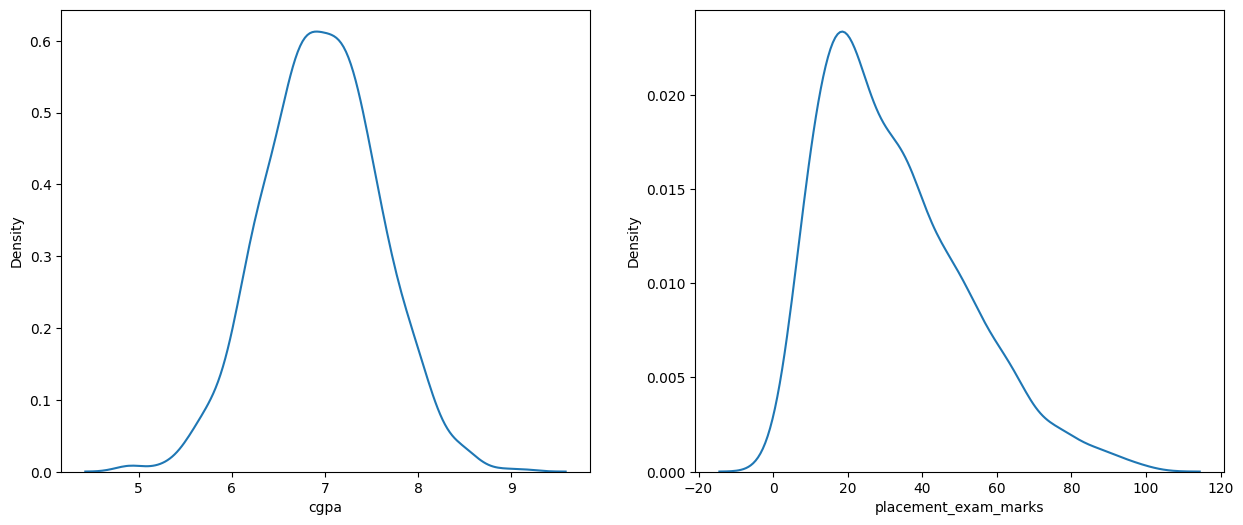

In [30]:
plt.figure(figsize=(15 , 6))
plt.subplot(1,  2 , 1)
sns.kdeplot(df['cgpa'])

plt.subplot(1 , 2 , 2)
sns.kdeplot(df['placement_exam_marks'])
plt.show()

In [31]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

Placement marks is skewed.

In [32]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

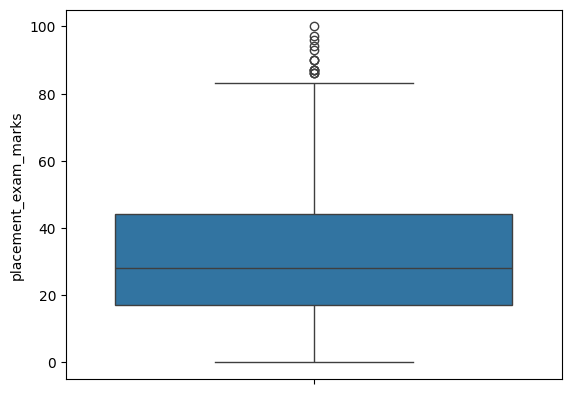

In [33]:
sns.boxplot(df['placement_exam_marks'])

In [34]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [35]:
percentile25, percentile75

(np.float64(17.0), np.float64(44.0))

In [36]:
iqr = percentile75 -  percentile25

In [37]:
iqr

np.float64(27.0)

In [38]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [39]:
print("Upper limit is " , upper_limit) 
print("Lower limit is " , lower_limit)

Upper limit is  84.5
Lower limit is  -23.5


In [40]:
df[df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [41]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


In [42]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [43]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


<Axes: ylabel='placement_exam_marks'>

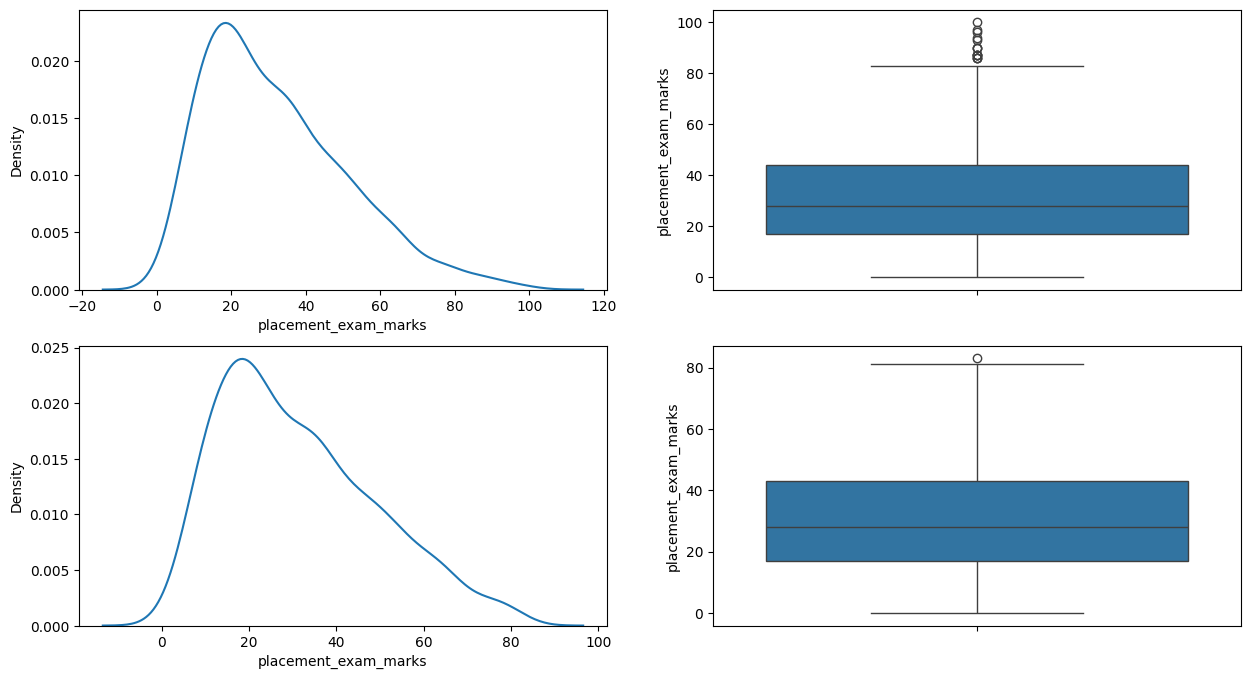

In [44]:
plt.figure(figsize=(15 , 8))
plt.subplot(2 , 2 , 1)
sns.kdeplot(df['placement_exam_marks'])
plt.subplot(2 , 2 , 2)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(2 , 2 , 3)
sns.kdeplot(new_df['placement_exam_marks'])
plt.subplot(2 , 2 , 4)
sns.boxplot(new_df['placement_exam_marks'])

## Capping

In [46]:
new_df_cap = df.copy()
new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks']>upper_limit , upper_limit , np.where(new_df_cap['placement_exam_marks']<lower_limit , lower_limit , new_df_cap['placement_exam_marks']))
new_df_cap

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


<Axes: ylabel='placement_exam_marks'>

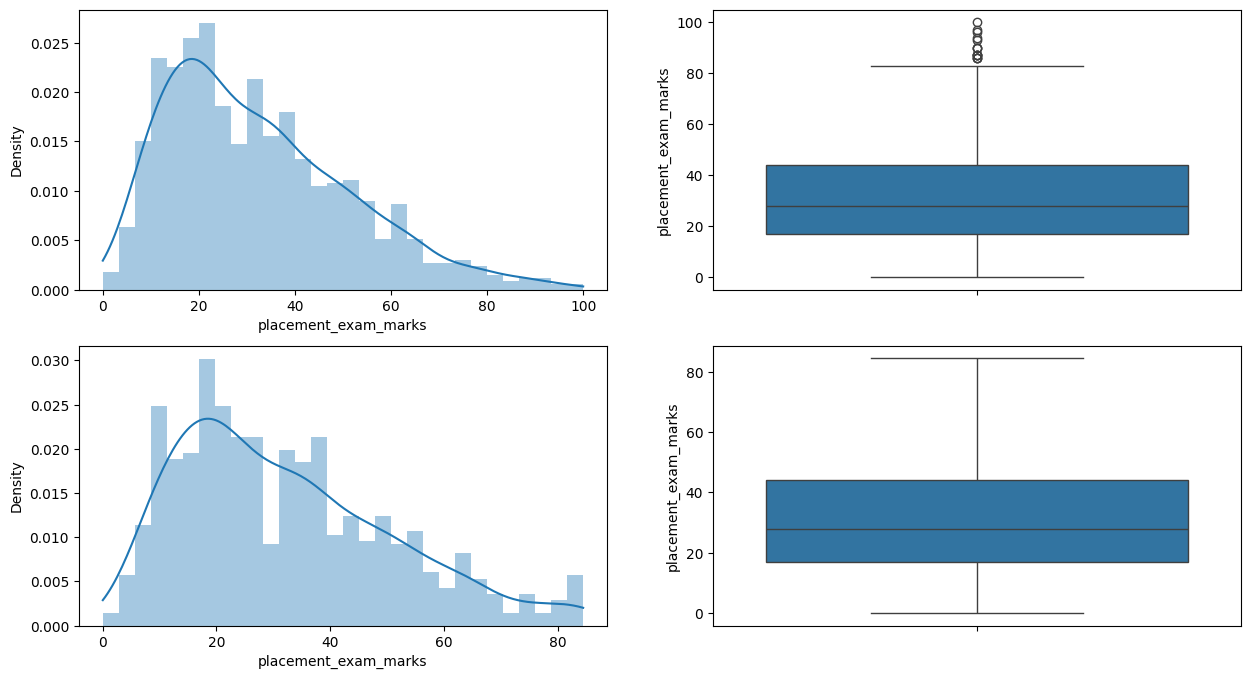

In [54]:
plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='placement_exam_marks', bins=30,
             stat='density', alpha=0.4, edgecolor=None , kde=True)
plt.subplot(2, 2, 2)
sns.boxplot(df['placement_exam_marks'])
plt.subplot(2, 2, 3)
sns.histplot(data=new_df_cap, x='placement_exam_marks', bins=30,
             stat='density', alpha=0.4, edgecolor=None , kde=True)
plt.subplot(2, 2, 4)
sns.boxplot(new_df_cap['placement_exam_marks'])